In [11]:
# import EDA & Data Processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import sys
from packaging import version
import sklearn

assert sys.version_info >= (3, 7) #This line checks that the version of Python being used is 3.7 or higher
assert version.parse(sklearn.__version__) >= version.parse("1.0.1") #This line checks that the version of Scikit-learn being used is 1.0.1 or higher.

In [12]:
# TASK 1
# Load/Explore dataset
from pathlib import Path # for filesystem paths
import tarfile # for the tar format of the dataset
import urllib.request # handles urls

# manages the tarfile for the dataset
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")

    if not tarball_path.is_file():
        # create dataset dir if it does not exist already
        Path("datasets").mkdir(parents=True, exist_ok=True)

        # url dataset from github
        url = "https://github.com/ageron/data/raw/main/housing.tgz"

        # download and open
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            # everything gets extracted in the dataset folder
            housing_tarball.extractall(path="datasets")
    # content is like a CSV file, we want to turn save use it as a pandas DataFrame
    return pd.read_csv(Path("datasets/housing/housing.csv"))

# call function to load up the dataframe
housing = load_housing_data()

In [13]:
# Overview of the data:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
# Summary of the dataframe
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [15]:
# e.g. count of unique values on "ocean_proximity", view distribution of categorical feature
housing["ocean_proximity"].value_counts()
# basically a distributed count for every single option under that category

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [16]:
# descriptive statistics for numerical columns on the DataFrame, it summarizing central tendency, dispersion, and shape of dataset distribution
housing.describe()
# basic statistics over categories

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


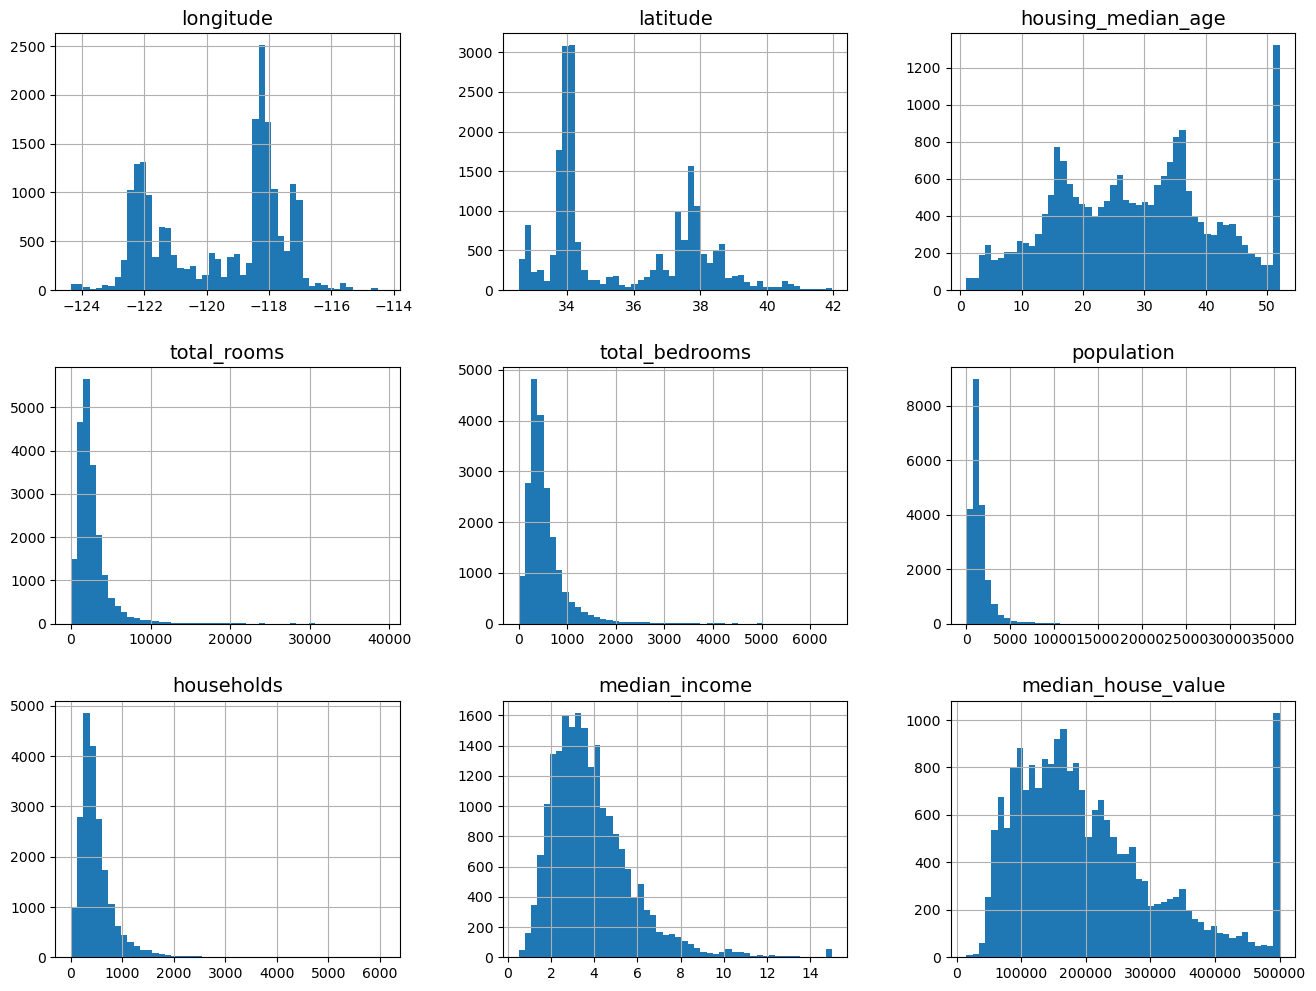

In [20]:
# matplotlib for histograms for each numerical column for Dataframe
# So all previous feature entries get can get a histogram using matplotlib

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(16, 12)) # Plot histograms with 50 bins and a figure size of 12x8 inches
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

In [21]:
# TASK 2 -- Create Test set

# the data we work with is split, so that the model will have something to be trained on, but also later tested on.
# it cannot be both trained and tested on the same data, because that generates bias
def shuffle_and_split_data(data, test_ratio):
    # shuffle the data randomly before splitting
    shuffled_indices = np.random.permutation(len(data)) # randomly shuffled array of indices 0 --> (data - 1)

    # size of test = test ratio
    test_set_size = int(len(data) * test_ratio)

    # select first part of indices as test
    test_indices = shuffled_indices[:test_set_size] # so everything up to that number will be put aside for the testing purpose

    # the remaining part is for training
    train_indices = shuffled_indices[test_set_size:]

    # return training/test based in index
    return data.iloc[train_indices], data.iloc[test_indices]

In [39]:
# we split the DataSet into a ratio of .8-train // .2-test
train_set, test_set = shuffle_and_split_data(housing, 0.2)

print(f'Training: {len(train_set)} || Test: {len(test_set)}')
# looks like a .8-.2 ratio

# every run of this would be different -- unless the same seed is run every time
# this should represent the number of entries with no information about the total number of bedrooms
# there is a little miss in the data, as every parameter has the same amount of entries, but not this one
print(f'{test_set["total_bedrooms"].isnull().sum()}')

np.random.seed(42)

Training: 16512 || Test: 4128
44


In [42]:
# can also do this by a default imported function
from sklearn.model_selection import train_test_split
# Split the housing data into a training set and a test set with a 20% test size
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42) # with the same ratio
# given the same seed, it should be able to produce the same results
print(f'Training: {len(train_set)} || Test: {len(test_set)}')
print(f'{test_set["total_bedrooms"].isnull().sum()}')
# which it does

Training: 16512 || Test: 4128
44


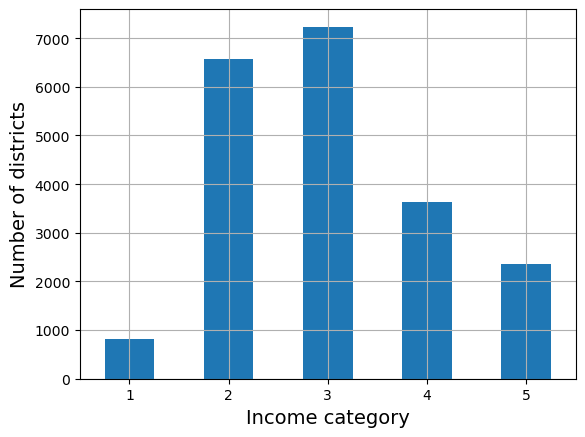

In [ ]:
# 5 categories from the median income
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
#save_fig("housing_income_cat_bar_plot")  # extra code
plt.show()

# so we have created 5 categories based on the median income entry -- so its like most of the people are middle class?

In [54]:
# this subgroup classification was made in order to be able to use stratification when it comes to sampling
# By actually dividing people in this extra subclassification, we will now be able to represent more proportionality when representing the groups
# That means that participants will be chosen randomly from within each group instead the whole population, its proportional, avoids bias

# will then compare stratify with purely random sampling

from sklearn.model_selection import StratifiedShuffleSplit  # Importing StratifiedShuffleSplit for creating stratified train-test splits

# Initialize the StratifiedShuffleSplit object with 10 splits, 20% test size, and a random state for reproducibility
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# Initialize an empty list to store the stratified splits
strat_splits = []

# iterate trough the generated splits
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    # Create the training set using the train indices
    strat_train_set_n = housing.iloc[train_index]

    # Create the test set using the test indices
    strat_test_set_n = housing.iloc[test_index]

    # Append the training and test sets as a pair to the list of stratified splits
    strat_splits.append([strat_train_set_n, strat_test_set_n])

# Extract the first pair of stratified training and test sets
strat_train_set, strat_test_set = strat_splits[0]
#this could also be achieved by the following (only 1 test case)
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

# calculate proportion of each income category within this test
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [55]:
# now we compare the random sampling in the whole dataset, in the particular stratified test and in a random slit test set.
# That helps in the evaluation of how well the stratified test preserves the original distribution

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


In [56]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

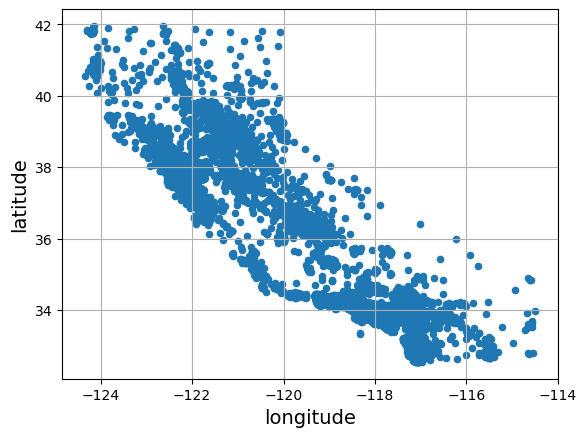

In [57]:
# TASK 3 - Discover and view the data -- gaining insights

# creating a copy of the stratified training set
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
#save_fig("bad_visualization_plot")  # extra code
plt.show()

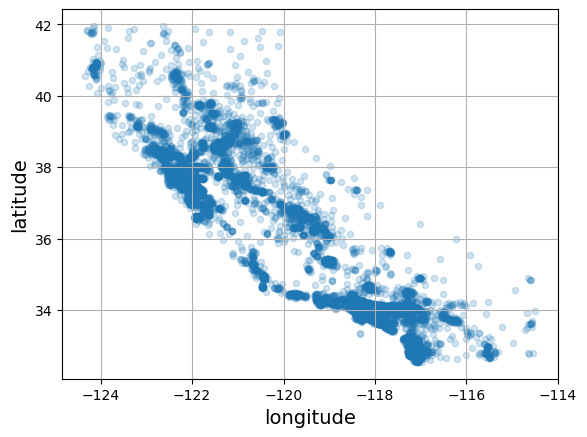

In [58]:
# giving it a certain transparency gives more insights into the dept and conglomeration around the contrast city | non-city
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
#save_fig("better_visualization_plot")  # extra code
plt.show()

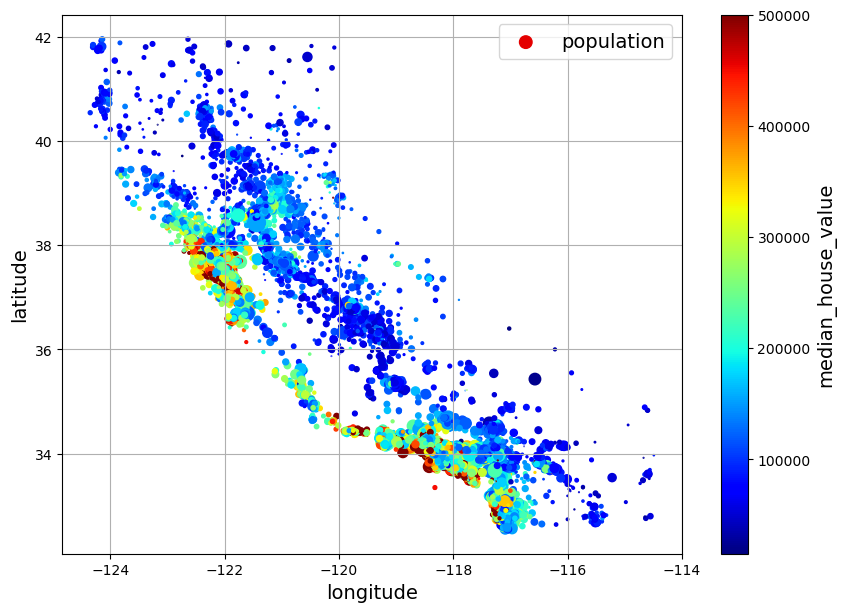

In [61]:
# complex scatter plot /w additional features & colors
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
#save_fig("housing_prices_scatterplot")  # extra code
# can even observe now that houses that are closer to the sea and are conglomerated more inside cities tend to raise in price compared to the more inline smaller city ones
plt.show()

In [ ]:
# correlations
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

# generally correlations and graphs are going by +1 - 0 - (-1), showing how much graphs follow each other and if they are actually connected somehow
# we check for correlations between every numerical column pair in the dataset, set it into a matrix and visualize it on the next point
# the result shows how strongly each feature relate to the median house price, basically how strongly does each feature affect the price?

# e.g. total_rooms display a very low relational -- the number of rooms does not increase the house prices much, median_income does much more -- richer area = higher price

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

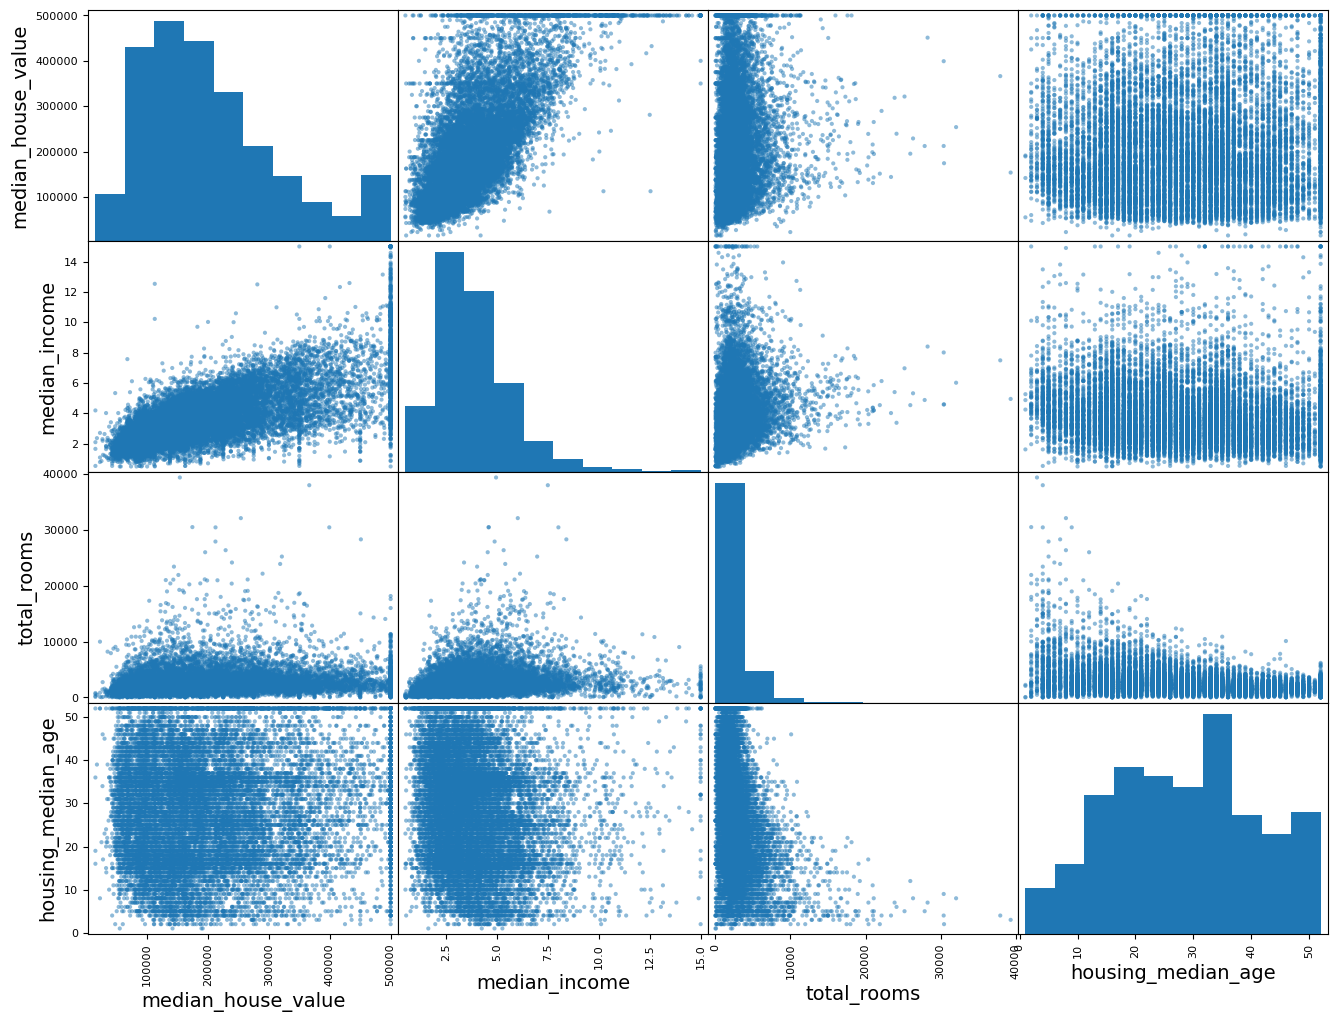

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(16, 12))
#save_fig("scatter_matrix_plot")  # extra code
plt.show()

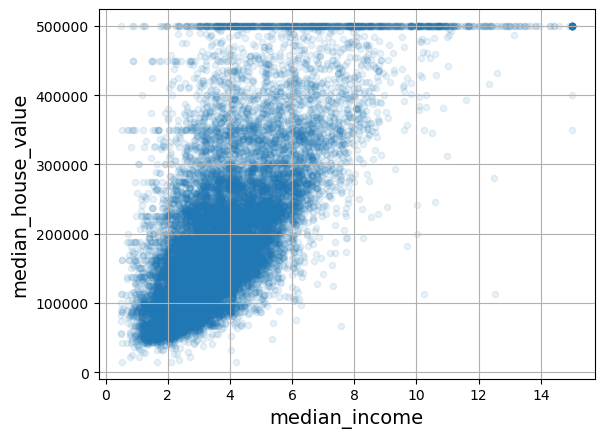

In [64]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
#save_fig("income_vs_house_value_scatterplot")  # extra code
plt.show()

In [ ]:
# experimentation with attribute combinations
# Feature engineering -- we create new columns by combining existing ones
# we do this to make up for the meaningless data, as total rooms is not really related to the price
# that is why we create rooms_per_house correlates better than its predecessor
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

# also the people_per_house is decreasing the housing prices, overcrowded areas tend to be cheaper
# the data must be engineer and researched, rather check what is relevant for the model than building it on pure raw data

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

In [67]:
# TASK 4 -- data cleaning
# preparing the data for ML algorithms

# Create a new DataFrame, housing, which contains all the features (input data) except the target variable, median_house_value
strat_housing = strat_train_set.drop("median_house_value", axis=1) # drop the column from the original dataset
# Create a new Series, housing_labels, which contains the target variable, median_house_value
strat_housing_labels = strat_train_set["median_house_value"].copy() # the target is saved here separately for external use, will be used for training the ML

housing.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  str    
 10  rooms_per_house     16512 non-null  float64
 11  bedrooms_ratio      16344 non-null  float64
 12  people_per_house    16512 non-null  float64
dtypes: float64(12), str(1)
memory usage: 1.8 MB


In [68]:
# there are some missing values based on the total_bedrooms data, have to fix that somehow
# checking for the null rows
null_rows_idx = strat_housing.isnull().any(axis=1)
strat_housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


In [72]:
# fix data -- option 1: we remove entirely the rows which are missing data
# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option1 = strat_housing.copy()

# Remove rows where the total_bedrooms column has missing values (Option 1)
strat_housing_option1.dropna(subset=["total_bedrooms"], inplace=True)

# Attempt to display the first five rows that still contain missing values (if any)
strat_housing_option1.loc[null_rows_idx].head()
# so now there are no such matches

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [74]:
# option 2 -- remove the entire column for the data with missing entries
# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option2 = strat_housing.copy()

# Remove the total_bedrooms column entirely (Option 2)
strat_housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # option 2

# Attempt to display the first five rows that still contain missing values (if any)
strat_housing_option2.loc[null_rows_idx].head()
# see no more column with NaN for bedrooms

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


In [ ]:
# option 3 -- filling the empty entries with the median value of that column
# as median, it is a robust value of central tendency, so its a good choice, it will not affect the outliers

# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option3 = strat_housing.copy()

# Calculate the median value of the total_bedrooms column in the housing DataFrame
median = strat_housing["total_bedrooms"].median()

# Fill the missing values in the total_bedrooms column of housing_option3 with the median value calculated in the previous step.
# deprecating inplace=True, it is not going to update the object itself, but rather a copy of it, needs fix -- Point out??
# The cleanest and most reliable way
strat_housing_option3["total_bedrooms"] = strat_housing_option3["total_bedrooms"].fillna(median)

strat_housing_option3.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN


In [78]:
# option 4 - SimpleImputer class -- basic strategies for imputing missing values, ensures a consistent way to handle missing data
# it can be based on a constant or statistics for each column which needs fixing

# Import the SimpleImputer class from the sklearn.impute module
from sklearn.impute import SimpleImputer

# Create an imputer instance with the strategy to fill missing values with the median value
imputer = SimpleImputer(strategy="median")

# Select only the numerical columns from the housing DataFrame and assign them to housing_num
# that is because we cannot calculate the mean for ocean_proximity, it is not a numerical value, the median is done only on numerical values
strat_housing_num = strat_housing.select_dtypes(include=[np.number])

# Fit the SimpleImputer instance to the numerical columns of the housing DataFrame
# This calculates the median values for each numerical column and stores them in the imputer
imputer.fit(strat_housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [79]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
strat_housing_num.median().values # learn the median values from the dataset
# same median values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
# Transform the numerical columns of the housing DataFrame using the fitted SimpleImputer
# This fills in missing values with the median values calculated during the fitting step
X = imputer.transform(strat_housing_num) # apply the values -- fill in the gaps basically
# Retrieve the names of the features that the SimpleImputer was fitted on
# This provides a list of column names that were included in the imputation process
imputer.feature_names_in_


array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [86]:
# Convert the NumPy array resulting from the imputation back into a DataFrame
# Restore the original column names and row indices from the housing_num DataFrame
strat_housing_tr = pd.DataFrame(X, columns=strat_housing_num.columns,
                          index=strat_housing_num.index)

In [87]:
strat_housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [ ]:
# dropping some outliers
from sklearn.ensemble import IsolationForest

# Create an instance of the IsolationForest with a fixed random state for reproducibility
isolation_forest = IsolationForest(random_state=42)

# Fit the IsolationForest model to the data and predict outliers
outlier_pred = isolation_forest.fit_predict(X)

# The fit_predict method returns an array where 1 indicates an inlier and -1 indicates an outlier
outlier_pred
# marked as -1 are basically anomalies, they exist, are statistically weird and should not exist?

array([-1,  1,  1, ...,  1,  1,  1], shape=(16512,))

In [89]:
# Extract the 'ocean_proximity' column from the housing DataFrame and assign it to housing_cat
strat_housing_cat = strat_housing[["ocean_proximity"]]

# Display the first 8 rows of the housing_cat DataFrame to preview the 'ocean_proximity' data
strat_housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [91]:
# we want to encode this into numerical values
# Import the OrdinalEncoder from sklearn.preprocessing
from sklearn.preprocessing import OrdinalEncoder

# Create an instance of the OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Fit the OrdinalEncoder to the housing_cat data and transform it into numerical values
strat_housing_cat_encoded = ordinal_encoder.fit_transform(strat_housing_cat)

strat_housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [92]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [ ]:
# TASK 5 -- Feature Scaling
# Scaling choice does affect the model performance

# general reason for scaling -- highlights the important of each feature on the same scale, instead of allowing just the bigger numbers dominate
# it basically uses proportional stretching

# Import the MinMaxScaler from sklearn.preprocessing
from sklearn.preprocessing import MinMaxScaler

# Create an instance of the MinMaxScaler with the feature range set to [-1, 1]
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit the MinMaxScaler to the housing_num data and transform it
# This scales each numerical feature to the range [-1, 1]
strat_housing_num_min_max_scaled = min_max_scaler.fit_transform(strat_housing_num)

# where in between min and max does the value sit at -- does not allow for values outside of that scope, it breaks easily there if new data arrives

In [ ]:
# standard scaling
# Import the StandardScaler from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
std_scaler = StandardScaler()

# Fit the StandardScaler to the housing_num data and transform it
# This standardizes each numerical feature by removing the mean and scaling to unit variance
strat_housing_num_std_scaled = std_scaler.fit_transform(strat_housing_num)

# everything sits around the mean of 0, it allows all sorts of values, but it returns the deviations from the mean
# if we get a standard mean of 0, most of the values will sit around there
# but even if we get a standard deviation then of + 1000, it will not break the model or highlight the outlier over the other values
# it will instead describe how unusual that outlier value is compared to what is usual, what is around the 0 mean

# it is generally better for all ML models, because real work data will always surprise the model with something outside of its train dataset

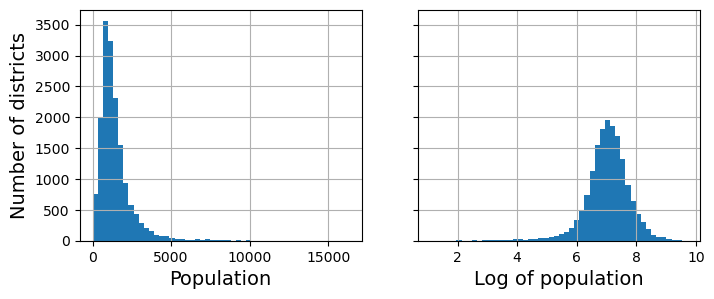

In [ ]:
# feature scaling for Heavy Tail Distribution, which we have a lot of
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
strat_housing["population"].hist(ax=axs[0], bins=50)
strat_housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
#save_fig("long_tail_plot")
plt.show()

# Log of population is in a bell shape, it actually shows the population distribution across each order (size of districts)
# It does not assume that the the same raw difference means the same thing for each size of district
# A district of 500 + 500 extra = double in size
# A district of 50 000 + 500 extra = basically noise to the main district, its not as significant

# the log instead:
# log(500)   → log(1,000)   = +0.69  (doubling the population)
# log(50,000) → log(100,000) = +0.69  (also doubling the population)
# so the differences are actually visible

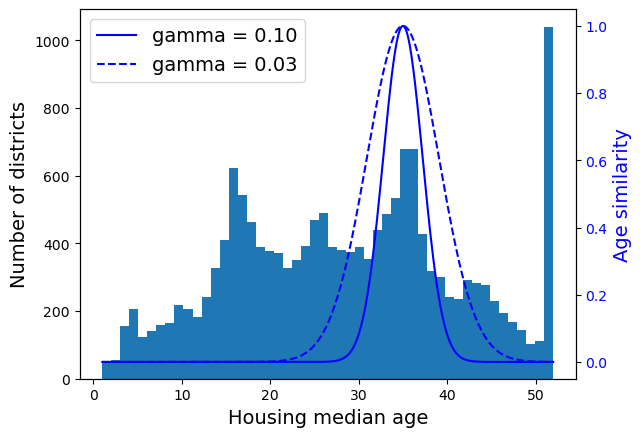

In [101]:
# Scaling for Multimodal Distributions
# Import the rbf_kernel function from sklearn.metrics.pairwise
from sklearn.metrics.pairwise import rbf_kernel
# Radial Basis function -- measures the similarity between a value & reference point

# Compute the RBF kernel similarity between the housing_median_age feature and the age 35
# The gamma parameter controls the influence of a single training example
age_simil_35 = rbf_kernel(strat_housing[["housing_median_age"]], [[35]], gamma=0.1)


# Compute the RBF kernel similarity between the housing_median_age feature and the age 35
# The gamma parameter controls the influence of a single training example
age_simil_35 = rbf_kernel(strat_housing[["housing_median_age"]], [[35]], gamma=0.1)

ages = np.linspace(strat_housing["housing_median_age"].min(),
                   strat_housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(strat_housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
#save_fig("age_similarity_plot")
plt.show()

# The RBF is allowing the model to learn better by storing and validating signals of the looked function, in this case age
# instead of just working with raw numbers, RBF respects the proximity of how close values are to the established reference point
# So proximity here is a meaningful signal

Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x167613e20>
Traceback (most recent call last):
  File "/Users/andreibors/miniconda3/envs/tam400/lib/python3.11/_weakrefset.py", line 39, in _remove
    def _remove(item, selfref=ref(self)):

KeyboardInterrupt: 


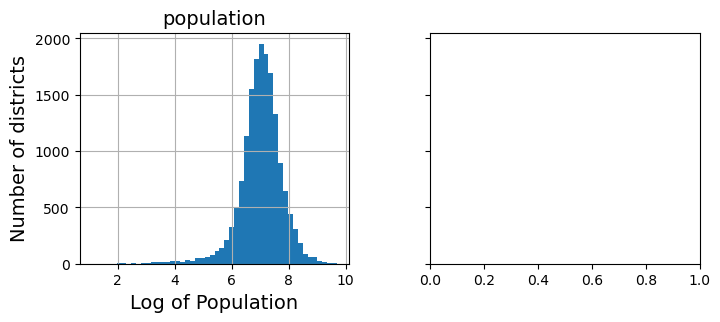

In [ ]:
# TASK 6 - Custom transformers & Transformation Pipeline
# Building and use transformers to generalize data and make functionality modular

# Import the FunctionTransformer from sklearn.preprocessing
from sklearn.preprocessing import FunctionTransformer

# Create a FunctionTransformer for the logarithmic transformation
# np.log applies the natural logarithm, and np.exp is the inverse function
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

# Apply the logarithmic transformation to the population feature
log_pop = log_transformer.transform(strat_housing[["population"]])
# this should do the same thing about the scale of the population:
fig, axs = plt.subplots(1, figsize=(8, 3), sharey=True)
log_pop.hist(ax=axs[0], bins=50)
axs[0].set_xlabel("Log of Population")
axs[0].set_ylabel("Number of districts")
#save_fig("long_tail_plot")
plt.show()